In [2]:
import pandas as pd
import numpy as np
from ml_utils.src import *
from ml_utils.config import *
import itertools
import gc 
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import  train_test_split

import keras
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from keras.regularizers import l2



print(tf.config.list_physical_devices())
BATCH_SIZE = 64

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


# 1.0 - Classificação de Presença Baseada em Fatores Socioeconômicos Usando Redes Neurais

In [3]:
colunas = ['Q001','Q002','Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 
           'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025', 'TP_PRESENCA_LC', 'TP_PRESENCA_CH', 'TP_PRESENCA_CN', 'TP_PRESENCA_MT', 
           'TP_FAIXA_ETARIA', 'TP_SEXO','TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_ESCOLA', 'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 
           'NU_ANO', 'TP_LOCALIZACAO_ESC','TP_SIT_FUNC_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_DEPENDENCIA_ADM_ESC']

df = pd.read_parquet(DATA_DIR, columns = colunas)

## 1.2- Pré-Processando os Dados

In [4]:
df = preparar_dados(df, objetivo = 'Desempenho', n_samples = 500_000)

## 1.3- Construção da Matriz X e Vetor y

In [5]:
X = df.drop(columns=['MEDIA', 'FALTOU'])
y = df['MEDIA']

## 1.4 - Separação em Dados de Treino, Validação e Teste

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [7]:
quantil = y_train.quantile(0.5)

y_train = (y_train >= quantil).astype(int)
y_val   = (y_val   >= quantil).astype(int)
y_test  = (y_test  >= quantil).astype(int)

## 1.5 - Tratando os Dados

In [8]:
preprocessador = pre_processor(X_train)

X_train = preprocessador.transform(X_train).astype(np.float32)
X_val   = preprocessador.transform(X_val).astype(np.float32)
X_test  = preprocessador.transform(X_test).astype(np.float32)

In [9]:
max_neurons = num_max_neuronio(X_train, d = X_train.shape[1])
print("Número máximo de neurônios:", max_neurons)

Número máximo de neurônios: 145


## 1.6 - Estourando a Rede Neural

In [ ]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(256, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(256, kernel_initializer='he_normal', activation='relu'))

model.add(Dense(1, kernel_initializer='he_normal', activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,081 (305.00 KB)

 Trainable params: 78,081 (305.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
history = model.fit(X_train, y_train, 
                    epochs=100,
                    validation_data=(X_val, y_val),
                    batch_size=BATCH_SIZE)

Epoch 1/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6978 - loss: 0.5777 - val_accuracy: 0.7015 - val_loss: 0.5688
Epoch 2/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7061 - loss: 0.5630 - val_accuracy: 0.7079 - val_loss: 0.5628
Epoch 3/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7103 - loss: 0.5584 - val_accuracy: 0.7102 - val_loss: 0.5597
Epoch 4/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7123 - loss: 0.5566 - val_accuracy: 0.7059 - val_loss: 0.5644
Epoch 5/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7120 - loss: 0.5547 - val_accuracy: 0.7099 - val_loss: 0.5609
Epoch 6/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7132 - loss: 0.5531 - val_accuracy: 0.7100 - val_loss: 0.5603
Epoch 7/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7148 - loss: 0.5511 - val_accuracy: 0.7065 - val_loss: 0.5630
Epoch 8/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7171 - loss: 0

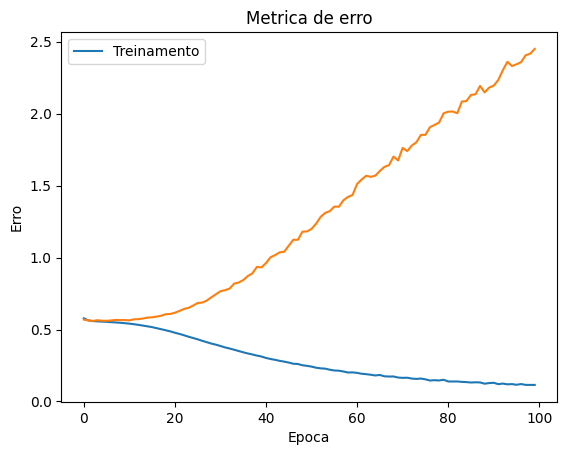


--> Acuracia (treino): 0.9641
--> Acuracia (teste): 0.6346
--> E_val - E_in = 2.3545
--> acc_train - acc_val = 0.3295


In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento'])
plt.show()

E_in, acc_train = model.evaluate(X_train, y_train, batch_size=BATCH_SIZE, verbose=0)

E_val, acc_val = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f'\n--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (teste): {acc_val:.4f}')
print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")

In [14]:
BATCH_SIZE = 64

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(256, kernel_initializer='he_normal', activation='relu',
          kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))

model.add(Dense(256, kernel_initializer='he_normal', activation='relu',
          kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))

model.add(Dense(1, kernel_initializer='he_normal', activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,081 (305.00 KB)

 Trainable params: 78,081 (305.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),   
)

Epoch 1/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6754 - loss: 1.0282 - val_accuracy: 0.6964 - val_loss: 0.7516
Epoch 2/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6985 - loss: 0.6834 - val_accuracy: 0.7094 - val_loss: 0.6241
Epoch 3/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7017 - loss: 0.6144 - val_accuracy: 0.7075 - val_loss: 0.5907
Epoch 4/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7027 - loss: 0.5935 - val_accuracy: 0.7048 - val_loss: 0.5838
Epoch 5/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7024 - loss: 0.5866 - val_accuracy: 0.7080 - val_loss: 0.5792
Epoch 6/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7022 - loss: 0.5834 - val_accuracy: 0.7087 - val_loss: 0.5742
Epoch 7/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7030 - loss: 0.5809 - val_accuracy: 0.7098 - val_loss: 0.5734
Epoch 8/100
1089/1089 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7030 - loss: 0

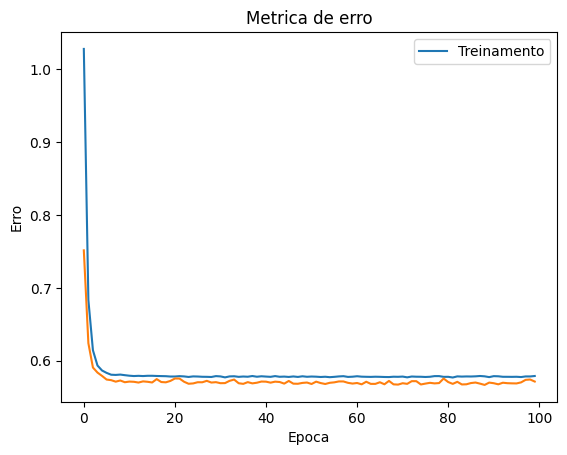


--> Acuracia (treino): 0.7016
--> Acuracia (teste): 0.7011
--> E_val - E_in = 0.0006
--> acc_train - acc_val = 0.0005


In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento'])
plt.show()

E_in, acc_train = model.evaluate(X_train, y_train, batch_size=BATCH_SIZE, verbose=0)

E_val, acc_val = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f'\n--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (teste): {acc_val:.4f}')
print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")

## 1.7 - Treinando a Rede Neural Respeitando a dimensão VC

In [17]:
max_neurons = num_max_neuronio(X_train, d = X_train.shape[1])
print("Número máximo de neurônios:", max_neurons)

Número máximo de neurônios: 145


In [ ]:
param_grid = {
    'neurons':       [max_neurons - 1],
    'learning_rate': [0.01, 0.001, 0.0001],   
    'batch_size':    [64],             
    'epochs':        [100],
    'l2_reg':        [0.001, 0.01, 0.1],          
    'dropout':       [0.0, 0.2],
}

# Gera todas as combinações
keys, values = zip(*param_grid.items())
combinacoes = [dict(zip(keys, v)) for v in itertools.product(*values)]
print(f"Total de combinações: {len(combinacoes)}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = []

for params in combinacoes:
    print(f"Testando: {params}")
    
    accs = []

    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = create_model(
            input_dim=X_train.shape[1],
            neurons=params['neurons'],
            learning_rate=params['learning_rate'],
            l2_reg=params['l2_reg'],
            dropout=params['dropout']
        )

        early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val_fold, y_val_fold),
            epochs=params['epochs'],  
            batch_size=params['batch_size'],
            callbacks=[early_stop],
            verbose=1
        )

        # Avaliação no fold
        loss, acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
        accs.append(acc)

        # Libera memória (importante no Keras)
        del model
        gc.collect()

    mean_acc = np.mean(accs)

    resultados.append({
        'params': params,
        'mean_accuracy': mean_acc
    })

    print(f"Accuracy média: {mean_acc:.4f}")

Total de combinações: 18
Testando: {'neurons': 144, 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 100, 'l2_reg': 0.001, 'dropout': 0.0}
Epoch 1/100
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6957 - loss: 0.6206 - val_accuracy: 0.7118 - val_loss: 0.5682
Epoch 2/100
871/871 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7005 - loss: 0.5798 - val_accuracy: 0.7082 - val_loss: 0.5655
Epoch 3/100
871/871 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7007 - loss: 0.5783 - val_accuracy: 0.7148 - val_loss: 0.5633
Epoch 4/100
871/871 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7003 - loss: 0.5765 - val_accuracy: 0.7044 - val_loss: 0.5659
Epoch 5/100
871/871 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7011 - loss: 0.5761 - val_accuracy: 0.7112 - val_loss: 0.5613
Epoch 6/100
871/871 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7017 - loss: 0.5751 - val_accuracy: 0.7120 - val_loss: 0.5612
Epoch 7/100
871/871 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7005 - loss: 0.575

### Salvando os resultados

In [19]:
resultados_df = pd.DataFrame(resultados)
resultados_df = resultados_df.sort_values(by='mean_accuracy', ascending=False)

In [21]:
resultados_df.to_csv("resultados_fatores_socioeconomicos.csv", index=False)

In [8]:
resultados_df = pd.read_csv("resultados_fatores_socioeconomicos.csv")
resultados_df.params[0]

"{'neurons': 144, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 100, 'l2_reg': 0.001, 'dropout': 0.2}"

## 1.8 - Treinando com todos os dados de treino

In [9]:
X = df.drop(columns=['MEDIA', 'FALTOU'])
y = df['MEDIA']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
quantil = y_train.quantile(0.5)

y_train = (y_train >= quantil).astype(int)
y_test  = (y_test  >= quantil).astype(int)

In [12]:
preprocessador = pre_processor(X_train)

X_train = preprocessador.transform(X_train).astype(np.float32)
X_test  = preprocessador.transform(X_test).astype(np.float32)

In [13]:
BATCH_SIZE = 64

adam = Adam(learning_rate=0.0001)

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(144, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.001), 
                activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, kernel_initializer='he_normal', activation='sigmoid'))

# Compilar o modelo
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 144)            │         6,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,913 (27.00 KB)

 Trainable params: 6,913 (27.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
history = model.fit(X_train, y_train, 
                    epochs=100,
                    batch_size=BATCH_SIZE)

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(X_train, y_train, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de teste
E_test, acc_test = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)

print(f"--> E_test - E_in = {E_test - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (teste): {acc_test:.4f}')
print(f"--> acc_train - acc_test = {acc_train - acc_test:.4f}")

Epoch 1/100
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 2s 935us/step - accuracy: 0.6496 - loss: 0.8756
Epoch 2/100
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 1s 917us/step - accuracy: 0.6904 - loss: 0.7461
Epoch 3/100
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 1s 908us/step - accuracy: 0.6978 - loss: 0.6934
Epoch 4/100
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 1s 918us/step - accuracy: 0.7008 - loss: 0.6634
Epoch 5/100
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 1s 911us/step - accuracy: 0.7025 - loss: 0.6449
Epoch 6/100
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 1s 918us/step - accuracy: 0.7060 - loss: 0.6311
Epoch 7/100
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 1s 950us/step - accuracy: 0.7046 - loss: 0.6220
Epoch 8/100
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 1s 922us/step - accuracy: 0.7067 - loss: 0.6135
Epoch 9/100
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 1s 934us/step - accuracy: 0.7071 - loss: 0.6062
Epoch 10/100
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7072 - loss: 0.6011
Epoch 11/100
1361/1361 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7073 - loss: 0.5969
E

In [17]:
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred))

681/681 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step
              precision    recall  f1-score   support

           0       0.69      0.75      0.72     10881
           1       0.73      0.67      0.70     10894

    accuracy                           0.71     21775
   macro avg       0.71      0.71      0.71     21775
weighted avg       0.71      0.71      0.71     21775

